# SEC Litigation Releases — Multi-Target Classification

Three classification tasks on SEC enforcement data:

| # | Task | Target Column | What it predicts |
|---|------|---------------|------------------|
| 1 | **Legal Topic** | `legal_topic` | Type of violation (Fraud, Insider Trading, …) |
| 2 | **Case Outcome** | `case_status` | Resolution (Settled, Final Judgment, Complaint filed) |
| 3 | **Industry Domain** | `company_domain` | Defendant's industry (Banking, Brokerage, Tech, …) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('All imports loaded.')

Matplotlib is building the font cache; this may take a moment.


All imports loaded.


## 1. Load & Explore the Data

In [2]:
df = pd.read_csv('sec_litigation_releases_20260403_234416.csv', encoding='utf-8', on_bad_lines='skip')
print(f'Loaded {len(df):,} rows × {len(df.columns)} columns')
df.head(2)

Loaded 10,914 rows × 39 columns


,case_title,citation,court,date,petitioner,respondent,defendant_roles,defendant_employer,employer_crd_cik,co_defendants,...,scheme_start_date,scheme_end_date,complaint_filed_date,judgment_date,regulatory_registrations,defendant_sentence,final_judgment_details,source_url,pdf_insights,associated_documents
0,SECURITIES AND EXCHANGE COMMISSION v. ELLIS L....,Litigation Release No. 14650 / 14650,District of Maine,"September 22, 1995",Securities and Exchange Commission (SEC),Ellis L. Deyon,NaN,the Commission's Office of\nInternational Affa...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.sec.gov/files/litigation/litreleas...,NaN,NaN
1,SECURITIES AND EXCHANGE COMMISSION v. CROSS FI...,Litigation Release No. 14649 / 14649,Central\n District of California,"September 21, 1995",Securities and Exchange Commission (SEC),"Owen R. Fox, Carroll E. Siemens, Bruce Frankli...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.sec.gov/files/litigation/litreleas...,NaN,NaN


In [3]:
target_cols = ['legal_topic', 'case_status', 'company_domain']
text_col = 'summary'

print('=== Target Column Coverage ===')
for col in target_cols:
    non_null = df[col].dropna().astype(str).str.strip().replace('', np.nan).dropna().shape[0]
    print(f'  {col:20s}: {non_null:,} / {len(df):,} ({non_null/len(df)*100:.1f}%)')

print(f'\n  {text_col:20s}: {df[text_col].notna().sum():,} non-empty (feature text)')
print(f'\n  Rows with ALL 3 targets + summary: ', end='')

mask = df[text_col].notna() & (df[text_col].str.len() > 50)
for col in target_cols:
    mask &= df[col].notna() & (df[col].astype(str).str.strip() != '')
print(f'{mask.sum():,}')

=== Target Column Coverage ===
  legal_topic         : 10,752 / 10,914 (98.5%)
  case_status         : 10,223 / 10,914 (93.7%)
  company_domain      : 9,095 / 10,914 (83.3%)

  summary             : 10,914 non-empty (feature text)

  Rows with ALL 3 targets + summary: 8,563


## 2. Preprocessing — Simplify Labels

The raw labels are multi-valued (semicolon-separated). We take the **primary (first)** label for each target and group rare categories into "Other".

In [4]:
def extract_primary_label(series, min_count=80):
    """Take first semicolon-separated value; bucket rare labels into 'Other'."""
    primary = series.astype(str).str.split(';').str[0].str.strip()
    primary = primary.replace(['', 'nan'], np.nan)
    counts = primary.value_counts()
    rare = counts[counts < min_count].index
    primary = primary.replace(rare, 'Other')
    return primary

df['topic'] = extract_primary_label(df['legal_topic'], min_count=80)
df['status'] = extract_primary_label(df['case_status'], min_count=50)
df['domain'] = extract_primary_label(df['company_domain'], min_count=80)

for col, orig in [('topic','legal_topic'), ('status','case_status'), ('domain','company_domain')]:
    print(f'\n--- {col} (from {orig}) ---')
    print(df[col].value_counts())


--- topic (from legal_topic) ---
topic
Broker-Dealer Violations      2168
Securities Fraud              2104
Insider Trading               1339
Books & Records               1143
Inv. Adviser Misconduct       1031
Unregistered Securities        585
Misappropriation               551
Material Misrepresentation     426
Ponzi Scheme                   377
Accounting Fraud               262
Crypto/Digital Assets          172
Market Manipulation            149
Other                          130
Internal Controls Failure      118
Offering Fraud                 107
Pump and Dump                   90
Name: count, dtype: int64

--- status (from case_status) ---
status
Complaint filed           3334
Settled/Consented         3261
Final judgment entered    2882
Pending                    674
Dismissed                   51
Other                       21
Name: count, dtype: int64

--- domain (from company_domain) ---
domain
Banking/Financial Services    2936
Brokerage                     1637
Other

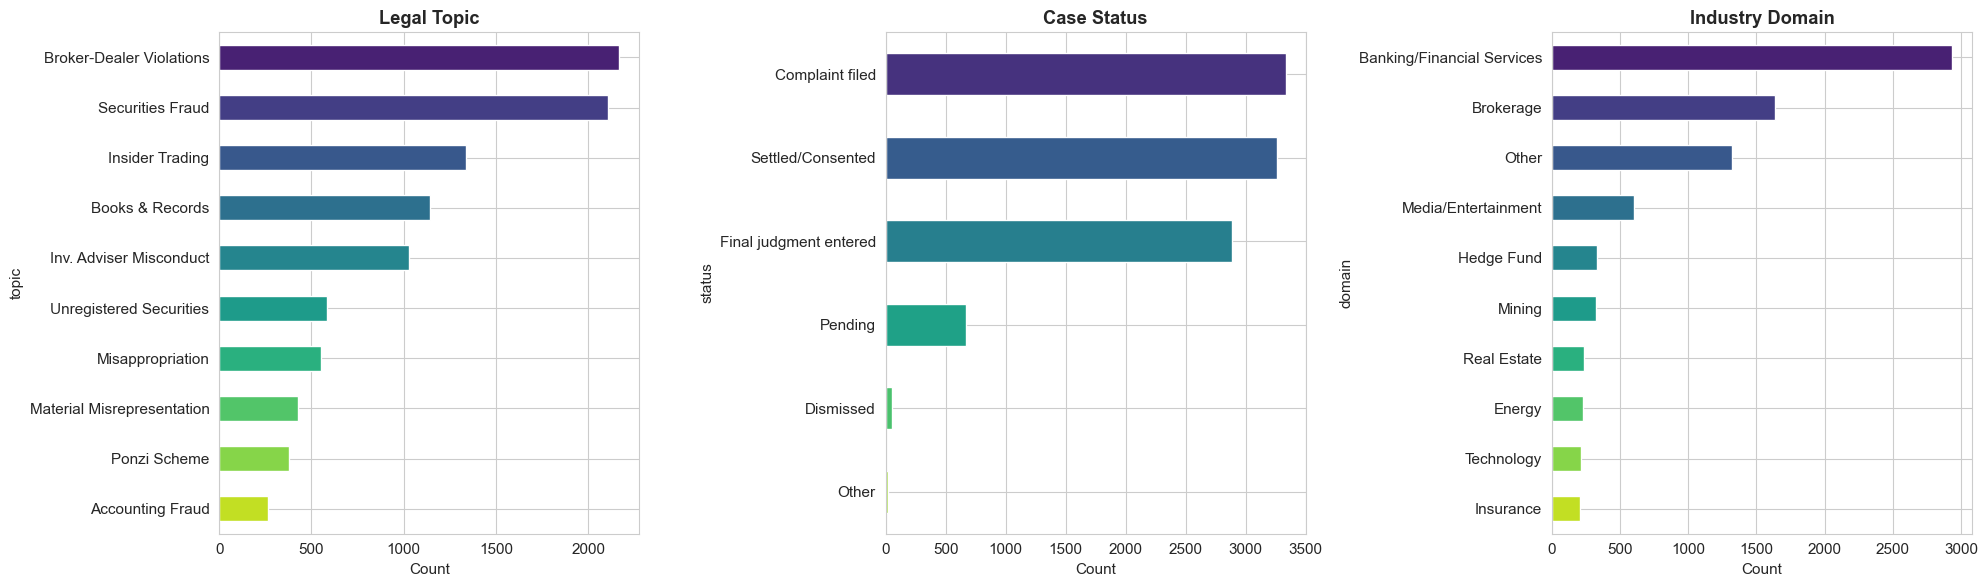

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col, title in zip(axes, ['topic', 'status', 'domain'],
                           ['Legal Topic', 'Case Status', 'Industry Domain']):
    counts = df[col].value_counts().head(10)
    counts.plot.barh(ax=ax, color=sns.color_palette('viridis', len(counts)))
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel('Count')

plt.tight_layout()
plt.savefig('label_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Build the Unified Dataset

Keep rows that have valid values for **all three targets** plus a non-trivial summary.

In [6]:
keep = df[text_col].notna() & (df[text_col].str.len() > 100)
for col in ['topic', 'status', 'domain']:
    keep &= df[col].notna()

data = df.loc[keep, [text_col, 'topic', 'status', 'domain',
                      'charges_and_sections', 'judgment_type',
                      'total_fine_amount', 'scheme_duration']].copy()
data = data.reset_index(drop=True)
print(f'Working dataset: {len(data):,} rows')

Working dataset: 8,563 rows


In [7]:
def clean_text(text):
    """Light cleaning: strip OCR artifacts, collapse whitespace."""
    import re
    text = str(text)
    text = re.sub(r'-{5,}.*?-{5,}', ' ', text)        # remove page-break markers
    text = re.sub(r'\s+', ' ', text).strip()
    return text[:5000]                                  # cap length for TF-IDF efficiency

data['clean_text'] = data[text_col].apply(clean_text)
print(f'Mean cleaned text length: {data["clean_text"].str.len().mean():.0f} chars')

Mean cleaned text length: 3381 chars


## 4. Feature Engineering

We build two feature sets:
- **Text features**: TF-IDF on the `summary` field (unigrams + bigrams)
- **Structured features**: charges, judgment type, fine amount, scheme duration

In [8]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    stop_words='english'
)

X_text = tfidf.fit_transform(data['clean_text'])
print(f'TF-IDF matrix: {X_text.shape}')
print(f'Top features: {tfidf.get_feature_names_out()[:20].tolist()}')

TF-IDF matrix: (8563, 10000)
Top features: ['00', '00 civ', '00 cv', '00 share', '000', '000 00', '000 000', '000 according', '000 addition', '000 based', '000 cash', '000 civil', '000 commission', '000 complaint', '000 court', '000 disgorgement', '000 final', '000 fine', '000 ill', '000 illegal']


In [9]:
charges_tfidf = TfidfVectorizer(max_features=200, analyzer='word', min_df=3)
X_charges = charges_tfidf.fit_transform(data['charges_and_sections'].fillna(''))

judgment_tfidf = TfidfVectorizer(max_features=50, analyzer='word', min_df=3)
X_judgment = judgment_tfidf.fit_transform(data['judgment_type'].fillna(''))

X_combined = hstack([X_text, X_charges, X_judgment])
print(f'Combined feature matrix: {X_combined.shape}')

Combined feature matrix: (8563, 10189)


## 5. Classification — All Three Tasks

We train and evaluate models for each target separately, then compare results.

In [10]:
TARGETS = {
    'Legal Topic':    'topic',
    'Case Status':    'status',
    'Industry Domain': 'domain',
}

MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, solver='saga', n_jobs=-1),
    'Linear SVC':          LinearSVC(max_iter=2000, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=30, n_jobs=-1, random_state=42),
}

results = []

In [11]:
from sklearn.model_selection import StratifiedKFold

for task_name, target_col in TARGETS.items():
    print(f'\n{"="*70}')
    print(f'  TASK: {task_name}  (target: {target_col})')
    print(f'{"="*70}')

    y = data[target_col].values
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    classes = le.classes_
    print(f'Classes ({len(classes)}): {list(classes)}')

    X_train, X_test, y_train, y_test = train_test_split(
        X_combined, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )
    print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

    for model_name, model in MODELS.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1_w = f1_score(y_test, y_pred, average='weighted')
        f1_m = f1_score(y_test, y_pred, average='macro')

        results.append({
            'Task': task_name,
            'Model': model_name,
            'Accuracy': acc,
            'F1 (weighted)': f1_w,
            'F1 (macro)': f1_m,
        })
        print(f'\n  {model_name:25s}  Acc={acc:.3f}  F1w={f1_w:.3f}  F1m={f1_m:.3f}')

    # Detailed report for best model (Linear SVC or Logistic Regression typically)
    best = LinearSVC(max_iter=2000, C=1.0)
    best.fit(X_train, y_train)
    y_pred_best = best.predict(X_test)
    print(f'\n  --- Detailed Classification Report (Linear SVC) ---')
    print(classification_report(y_test, y_pred_best, target_names=classes, zero_division=0))


  TASK: Legal Topic  (target: topic)
Classes (16): ['Accounting Fraud', 'Books & Records', 'Broker-Dealer Violations', 'Crypto/Digital Assets', 'Insider Trading', 'Internal Controls Failure', 'Inv. Adviser Misconduct', 'Market Manipulation', 'Material Misrepresentation', 'Misappropriation', 'Offering Fraud', 'Other', 'Ponzi Scheme', 'Pump and Dump', 'Securities Fraud', 'Unregistered Securities']
Train: 6,850  |  Test: 1,713



  Logistic Regression        Acc=0.646  F1w=0.616  F1m=0.407



  Linear SVC                 Acc=0.687  F1w=0.676  F1m=0.546



  Random Forest              Acc=0.656  F1w=0.613  F1m=0.380



  --- Detailed Classification Report (Linear SVC) ---
                            precision    recall  f1-score   support

          Accounting Fraud       0.78      0.74      0.76        47
           Books & Records       0.70      0.69      0.69       204
  Broker-Dealer Violations       0.68      0.72      0.70       400
     Crypto/Digital Assets       0.73      0.61      0.67        31
           Insider Trading       0.89      0.94      0.91       217
 Internal Controls Failure       0.25      0.10      0.14        20
   Inv. Adviser Misconduct       0.72      0.80      0.76       174
       Market Manipulation       0.47      0.30      0.37        23
Material Misrepresentation       0.56      0.49      0.52        75
          Misappropriation       0.56      0.40      0.47        84
            Offering Fraud       0.33      0.11      0.16        19
                     Other       0.55      0.29      0.38        21
              Ponzi Scheme       0.66      0.54      0.59   

...


  --- Detailed Classification Report (Linear SVC) ---
                        precision    recall  f1-score   support

       Complaint filed       0.82      0.93      0.87       605
             Dismissed       1.00      0.14      0.25         7
Final judgment entered       0.89      0.84      0.86       438
                 Other       0.00      0.00      0.00         3
               Pending       0.76      0.39      0.52       115
     Settled/Consented       0.84      0.85      0.84       545

              accuracy                           0.84      1713
             macro avg       0.72      0.53      0.56      1713
          weighted avg       0.84      0.84      0.83      1713


  TASK: Industry Domain  (target: domain)
Classes (18): ['Banking/Financial Services', 'Biotechnology', 'Brokerage', 'Construction', 'Energy', 'Hedge Fund', 'Insurance', 'Investment Advisory', 'Investment Fund', 'Media/Entertainment', 'Mining', 'Oil & Gas/Energy', 'Other', 'Pharmaceuticals', 'Real Es


  Logistic Regression        Acc=0.583  F1w=0.541  F1m=0.358



  Linear SVC                 Acc=0.688  F1w=0.684  F1m=0.640



  Random Forest              Acc=0.597  F1w=0.546  F1m=0.359



  --- Detailed Classification Report (Linear SVC) ---
                            precision    recall  f1-score   support

Banking/Financial Services       0.72      0.80      0.76       548
             Biotechnology       0.86      0.63      0.73        19
                 Brokerage       0.71      0.75      0.73       313
              Construction       0.71      0.26      0.38        19
                    Energy       0.86      0.59      0.70        41
                Hedge Fund       0.81      0.86      0.83        63
                 Insurance       0.86      0.50      0.63        38
       Investment Advisory       0.55      0.55      0.55        33
           Investment Fund       1.00      0.52      0.69        21
       Media/Entertainment       0.54      0.47      0.50       114
                    Mining       0.57      0.55      0.56        56
          Oil & Gas/Energy       0.86      0.71      0.77        17
                     Other       0.57      0.68      0.62   

## 6. Results Summary

In [12]:
res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))
res_df

           Task               Model  Accuracy  F1 (weighted)  F1 (macro)
    Legal Topic Logistic Regression  0.646235       0.615898    0.406709
    Legal Topic          Linear SVC  0.686515       0.675995    0.546495
    Legal Topic       Random Forest  0.656159       0.612590    0.379716
    Case Status Logistic Regression  0.823117       0.811309    0.490150
    Case Status          Linear SVC  0.839463       0.831875    0.557264
    Case Status       Random Forest  0.837128       0.817612    0.472469
Industry Domain Logistic Regression  0.583187       0.541204    0.357972
Industry Domain          Linear SVC  0.688266       0.684216    0.639663
Industry Domain       Random Forest  0.596614       0.546135    0.358859


,Task,Model,Accuracy,F1 (weighted),F1 (macro)
0,Legal Topic,Logistic Regression,0.646235,0.615898,0.406709
1,Legal Topic,Linear SVC,0.686515,0.675995,0.546495
2,Legal Topic,Random Forest,0.656159,0.612590,0.379716
3,Case Status,Logistic Regression,0.823117,0.811309,0.490150
4,Case Status,Linear SVC,0.839463,0.831875,0.557264
5,Case Status,Random Forest,0.837128,0.817612,0.472469
6,Industry Domain,Logistic Regression,0.583187,0.541204,0.357972
7,Industry Domain,Linear SVC,0.688266,0.684216,0.639663
8,Industry Domain,Random Forest,0.596614,0.546135,0.358859


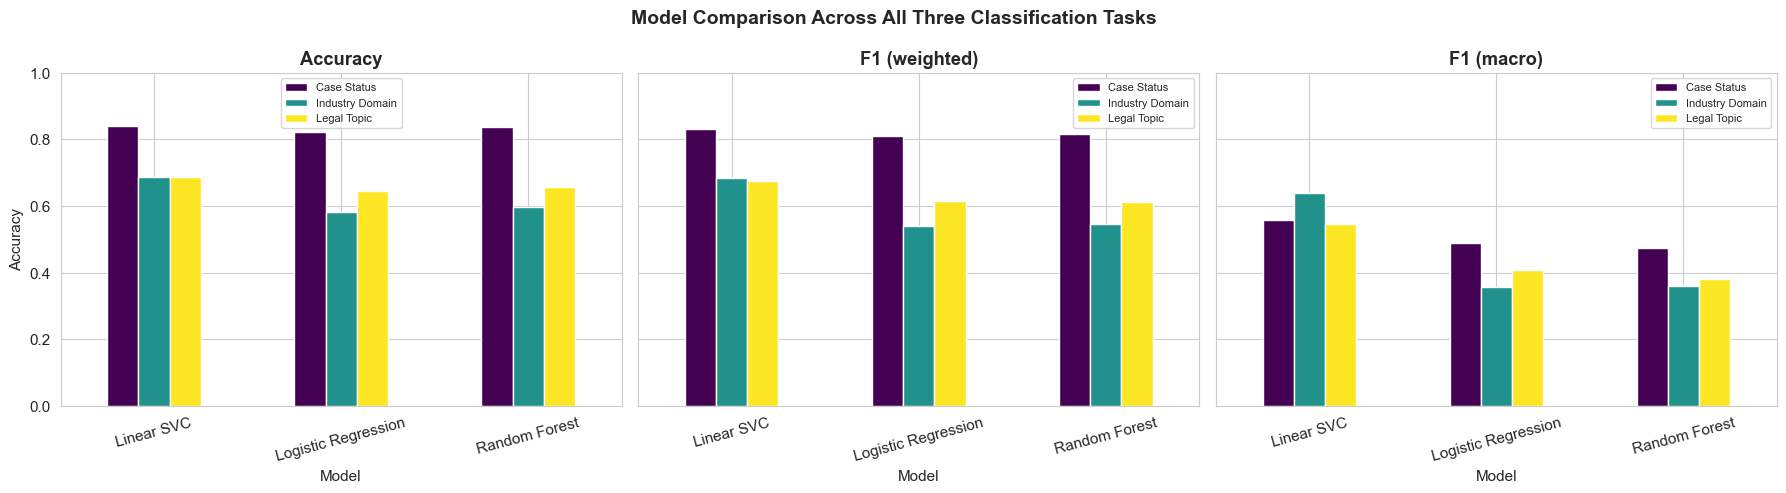

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

metrics = ['Accuracy', 'F1 (weighted)', 'F1 (macro)']
for ax, metric in zip(axes, metrics):
    pivot = res_df.pivot(index='Model', columns='Task', values=metric)
    pivot.plot.bar(ax=ax, rot=15, colormap='viridis')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)

plt.suptitle('Model Comparison Across All Three Classification Tasks', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Confusion Matrices

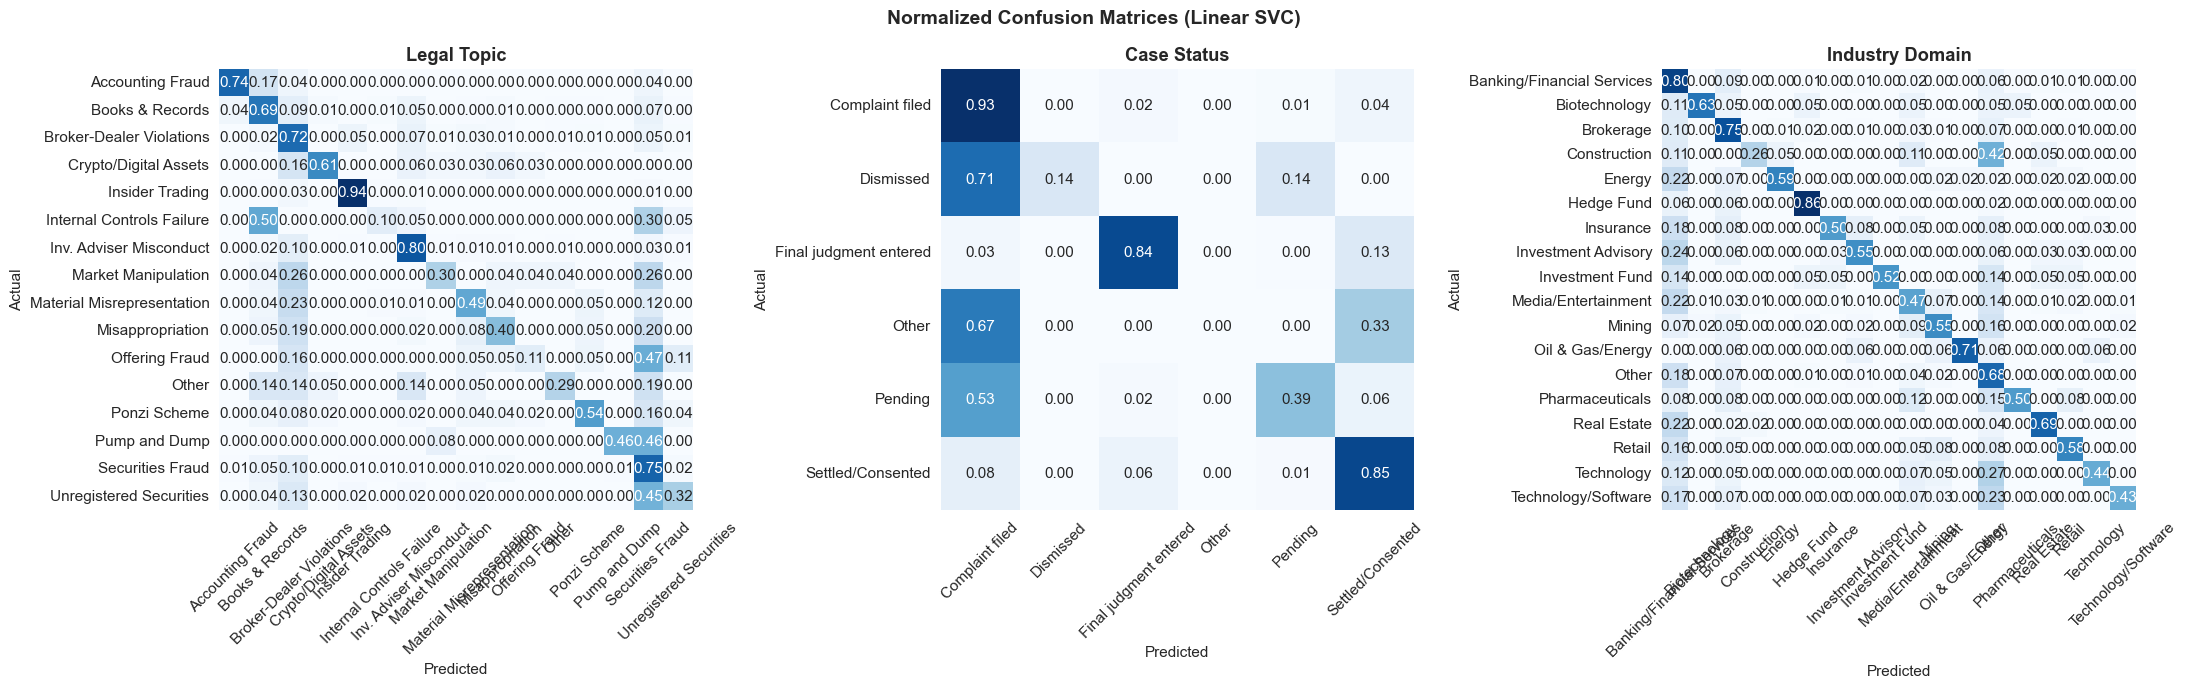

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (task_name, target_col) in zip(axes, TARGETS.items()):
    y = data[target_col].values
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X_combined, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    model = LinearSVC(max_iter=2000, C=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, cbar=False)
    ax.set_title(f'{task_name}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Normalized Confusion Matrices (Linear SVC)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cross-Validation (5-Fold) — Best Model

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"Task":20s} {"Mean Acc":>10s} {"Std":>8s} {"Mean F1w":>10s} {"Std":>8s}')
print('-' * 60)

for task_name, target_col in TARGETS.items():
    y = LabelEncoder().fit_transform(data[target_col].values)
    model = LinearSVC(max_iter=2000, C=1.0)

    acc_scores = cross_val_score(model, X_combined, y, cv=cv, scoring='accuracy', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_combined, y, cv=cv, scoring='f1_weighted', n_jobs=-1)

    print(f'{task_name:20s} {acc_scores.mean():10.3f} {acc_scores.std():8.3f} '
          f'{f1_scores.mean():10.3f} {f1_scores.std():8.3f}')

Task                   Mean Acc      Std   Mean F1w      Std
------------------------------------------------------------


Legal Topic               0.694    0.011      0.683    0.012


Case Status               0.830    0.009      0.822    0.009


Industry Domain           0.693    0.011      0.686    0.014


## 9. Feature Importance — What Words Drive Each Classification?

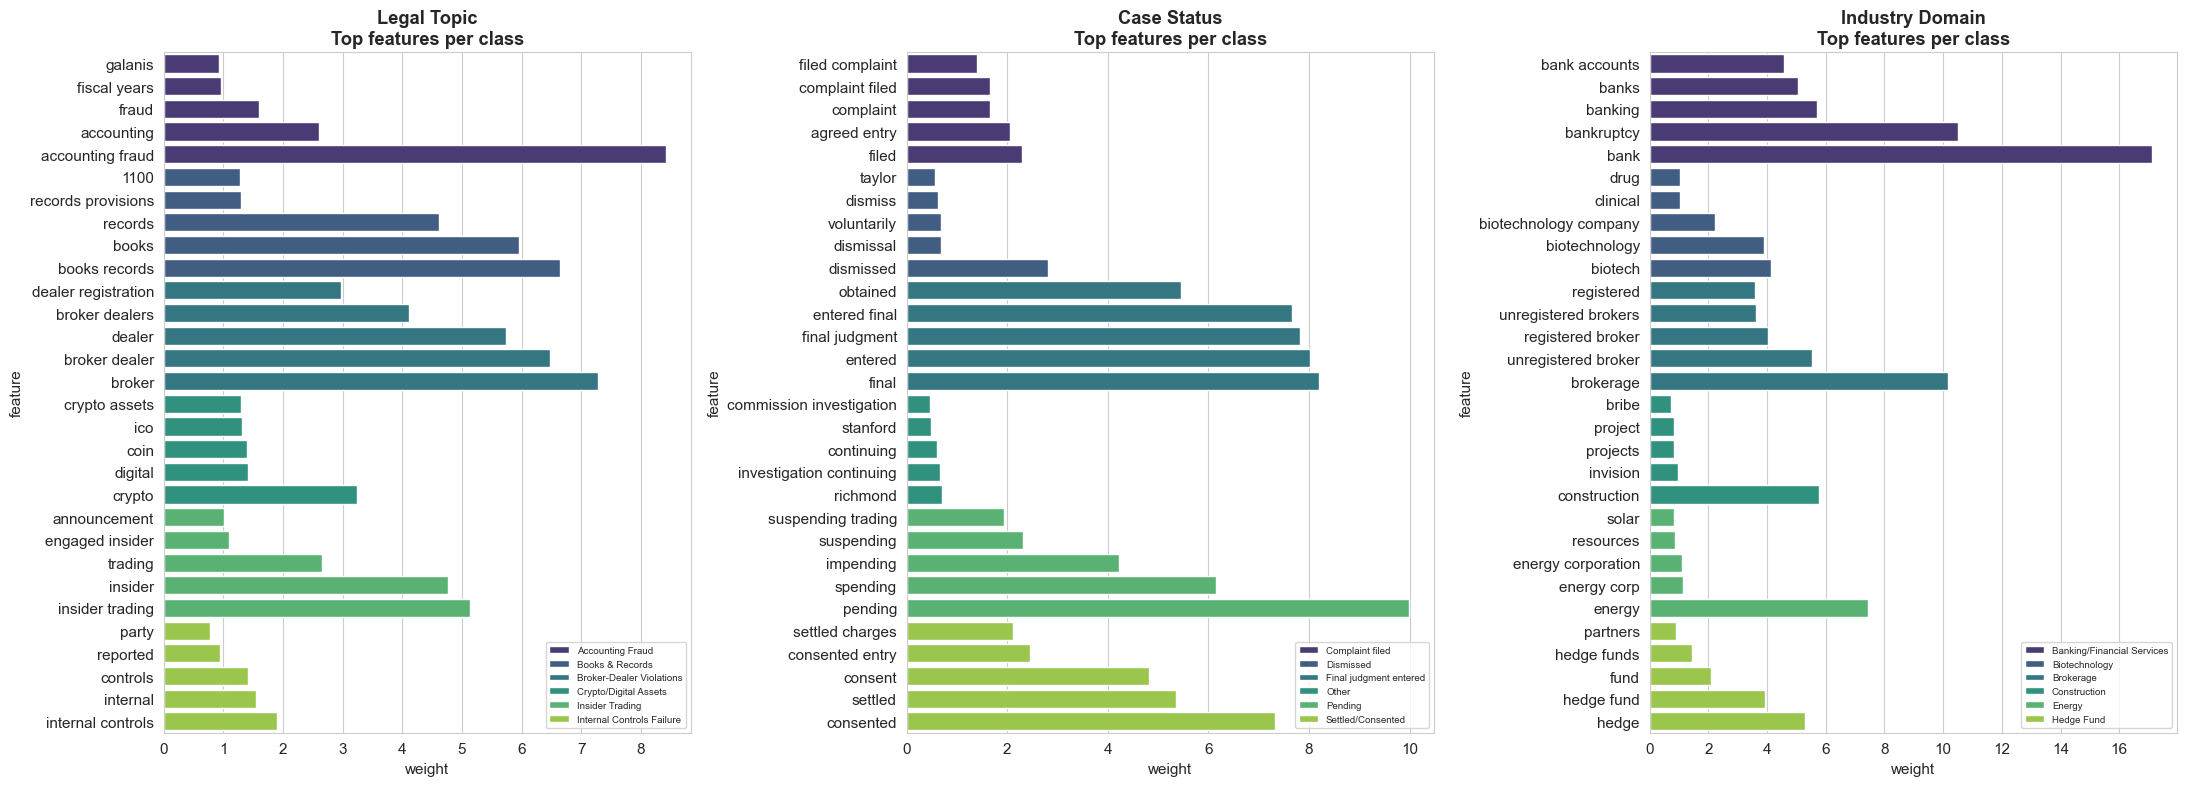

In [16]:
all_feature_names = np.concatenate([
    tfidf.get_feature_names_out(),
    charges_tfidf.get_feature_names_out(),
    judgment_tfidf.get_feature_names_out()
])

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for ax, (task_name, target_col) in zip(axes, TARGETS.items()):
    y = data[target_col].values
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    model = LinearSVC(max_iter=2000, C=1.0)
    model.fit(X_combined, y_enc)

    # For each class, get the top-5 most important features
    top_n = 5
    classes_to_show = le.classes_[:6]  # show up to 6 classes
    rows_data = []
    for i, cls in enumerate(classes_to_show):
        if i >= model.coef_.shape[0]:
            break
        coefs = model.coef_[i]
        top_idx = np.argsort(coefs)[-top_n:]
        for idx in top_idx:
            rows_data.append({'class': cls, 'feature': all_feature_names[idx], 'weight': coefs[idx]})

    imp_df = pd.DataFrame(rows_data)
    if len(imp_df) > 0:
        sns.barplot(data=imp_df, y='feature', x='weight', hue='class', dodge=False, ax=ax,
                    palette='viridis')
    ax.set_title(f'{task_name}\nTop features per class', fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Quick Prediction Demo

Pass any SEC case summary text and get all three predictions at once.

In [17]:
# Train final models on full data
final_models = {}
label_encoders = {}

for task_name, target_col in TARGETS.items():
    le = LabelEncoder()
    y = le.fit_transform(data[target_col].values)
    model = LinearSVC(max_iter=2000, C=1.0)
    model.fit(X_combined, y)
    final_models[task_name] = model
    label_encoders[task_name] = le

def predict_case(summary_text, charges='', judgment=''):
    """Predict all three targets for a given case summary."""
    x_t = tfidf.transform([clean_text(summary_text)])
    x_c = charges_tfidf.transform([charges])
    x_j = judgment_tfidf.transform([judgment])
    x = hstack([x_t, x_c, x_j])

    predictions = {}
    for task_name in TARGETS:
        pred = final_models[task_name].predict(x)[0]
        label = label_encoders[task_name].inverse_transform([pred])[0]
        predictions[task_name] = label
    return predictions

# Example
sample_text = data['clean_text'].iloc[0]
sample_charges = str(data['charges_and_sections'].iloc[0])
sample_judgment = str(data['judgment_type'].iloc[0])

preds = predict_case(sample_text, sample_charges, sample_judgment)
print('=== Multi-Target Prediction ===')
for task, label in preds.items():
    print(f'  {task:20s} → {label}')

print(f'\n  (Actual: topic={data["topic"].iloc[0]}, status={data["status"].iloc[0]}, domain={data["domain"].iloc[0]})')

=== Multi-Target Prediction ===
  Legal Topic          → Broker-Dealer Violations
  Case Status          → Settled/Consented
  Industry Domain      → Banking/Financial Services

  (Actual: topic=Broker-Dealer Violations, status=Settled/Consented, domain=Banking/Financial Services)
